# Metaheuristic Path Planning Algorithms

This notebook demonstrates the path planning algorithms based on metaheuristic optimization available in the `pathplan` library, utilizing the `metaheuropt` library.

In [11]:
import numpy as np
from pathplan.core import GridMap
from pathplan.metaheuristic import (
    GAPlanner,
    PSOPlanner,
    GWOPlanner,
    WOAPlanner
)
from pathplan.utils import Visualizer

In [12]:
# Recreating the scenario map parameters
maze_data = np.zeros((20, 20))

# Vertical wall with an open gap
maze_data[5:15, 10] = 1.0
maze_data[10, 10] = 0.0  

# Horizontal wall with an open gap
maze_data[12, 3:17] = 1.0
maze_data[12, 8] = 0.0   

# Static block obstacles
maze_data[3:5, 3:5] = 1.0
maze_data[7:9, 15:18] = 1.0
maze_data[16:18, 5:7] = 1.0

# Define start and goal configurations (row, col indices)
start_node = (0.0, 0.0)
goal_node = (19.0, 19.0)

# Instantiate the normalized GridMap wrapper
grid_map = GridMap(maze_data)
print(f"GridMap successfully initialized with shape: {grid_map.shape}")

GridMap successfully initialized with shape: (20, 20)



Running Genetic Algorithm (GA)...

Optimizing with: GA



========================= GLOBAL SUMMARY =========================
Algorithm    | Mean Best    | Std Dev      | Avg Time (s)
-----------------------------------------------------------------
GA           | 3.3270e+01   | 0.0000e+00   | 3.20        
-----------------------------------------------------------------
SUCCESS: Valid trajectory discovered for Genetic Algorithm (GA)!
Total waypoints in path: 12


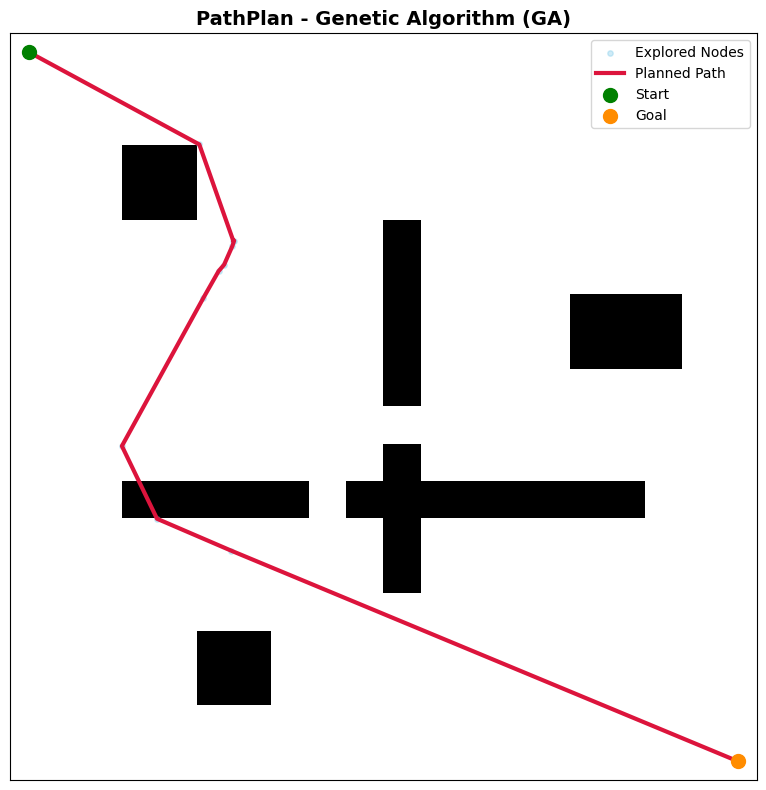


Running Particle Swarm Optimization (PSO)...

Optimizing with: PSO



========================= GLOBAL SUMMARY =========================
Algorithm    | Mean Best    | Std Dev      | Avg Time (s)
-----------------------------------------------------------------
PSO          | 2.7497e+01   | 0.0000e+00   | 2.57        
-----------------------------------------------------------------
SUCCESS: Valid trajectory discovered for Particle Swarm Optimization (PSO)!
Total waypoints in path: 12


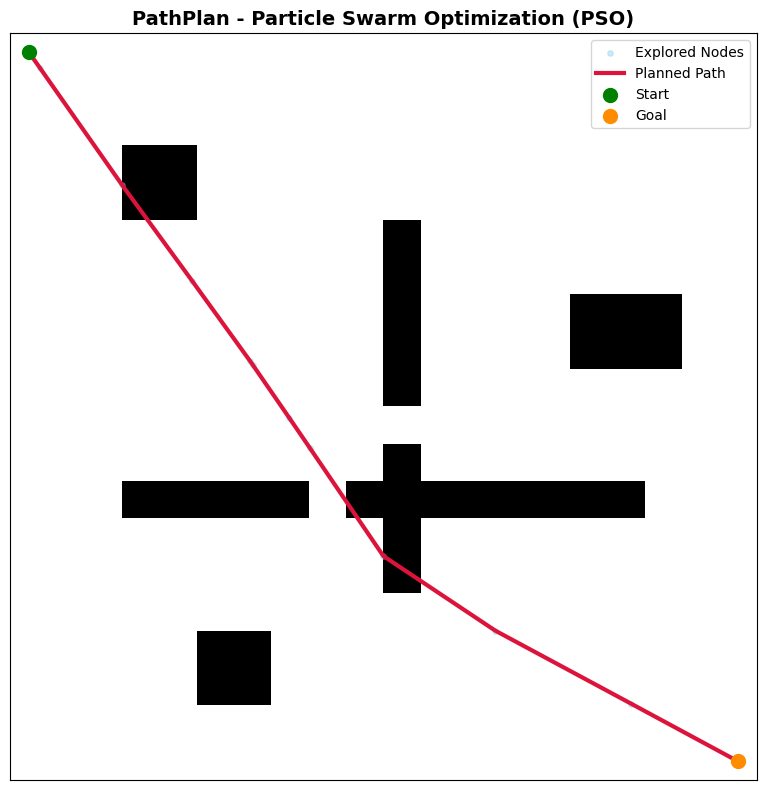


Running Grey Wolf Optimizer (GWO)...

Optimizing with: GWO



========================= GLOBAL SUMMARY =========================
Algorithm    | Mean Best    | Std Dev      | Avg Time (s)
-----------------------------------------------------------------
GWO          | 3.0258e+01   | 0.0000e+00   | 3.24        
-----------------------------------------------------------------
SUCCESS: Valid trajectory discovered for Grey Wolf Optimizer (GWO)!
Total waypoints in path: 12


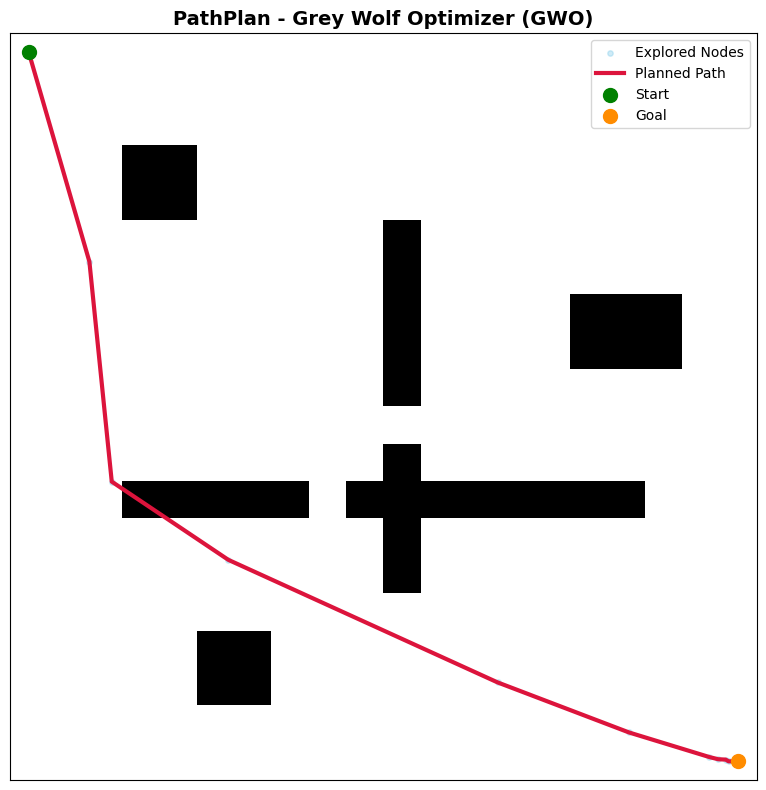


Running Whale Optimization Algorithm (WOA)...

Optimizing with: WOA



========================= GLOBAL SUMMARY =========================
Algorithm    | Mean Best    | Std Dev      | Avg Time (s)
-----------------------------------------------------------------
WOA          | 3.1834e+01   | 0.0000e+00   | 2.68        
-----------------------------------------------------------------
SUCCESS: Valid trajectory discovered for Whale Optimization Algorithm (WOA)!
Total waypoints in path: 12


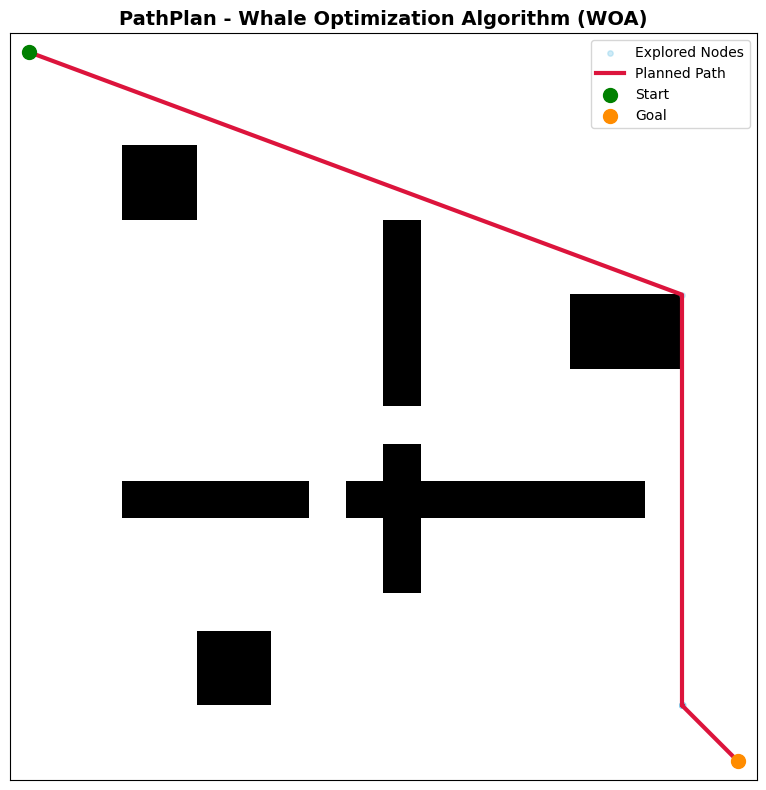

In [13]:
# Define the metaheuristic planners to demonstrate
# Each transforms path planning into a continuous optimization problem
# using waypoints as decision variables.
planners = [
    ("Genetic Algorithm (GA)", GAPlanner(grid_map, num_waypoints=10, pop_size=100, max_iter=200)),
    ("Particle Swarm Optimization (PSO)", PSOPlanner(grid_map, num_waypoints=10, pop_size=100, max_iter=200)),
    ("Grey Wolf Optimizer (GWO)", GWOPlanner(grid_map, num_waypoints=10, pop_size=100, max_iter=200)),
    ("Whale Optimization Algorithm (WOA)", WOAPlanner(grid_map, num_waypoints=10, pop_size=100, max_iter=200)),
]

viz = Visualizer(grid_map)

for name, planner in planners:
    print(f"\nRunning {name}...")
    path, explored = planner.plan(start_node, goal_node)
    
    if path:
        print(f"SUCCESS: Valid trajectory discovered for {name}!")
        print(f"Total waypoints in path: {len(path)}")
        viz.plot_path(
            path=path, 
            explored=explored, 
            title=f"PathPlan - {name}"
        )
    else:
        print(f"FAILURE: {name} could not find a valid path.")
        if explored:
            print("Showing best candidate waypoints (with collisions):")
            viz.plot_path(
                path=None, 
                explored=explored, 
                title=f"PathPlan - {name} (Best Candidate with Collisions)"
            )